<a href="https://colab.research.google.com/github/Jayapriya49/Applied-AI/blob/main/ex9A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Screenshot 2026-03-30 161840.png to Screenshot 2026-03-30 161840.png


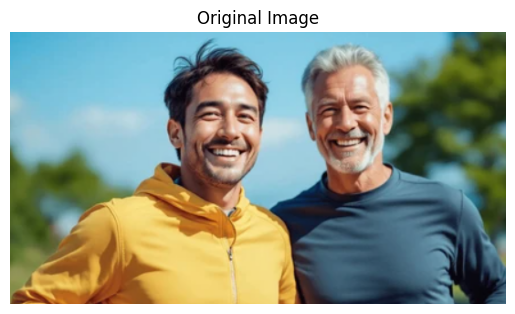

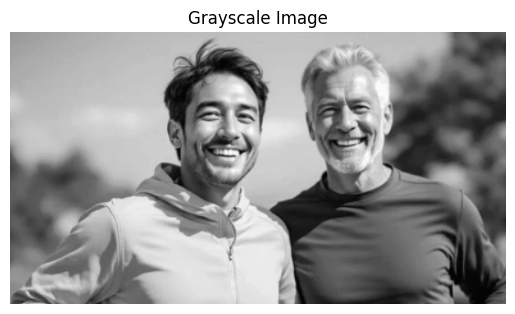

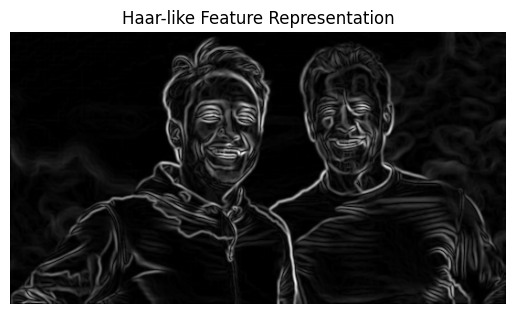

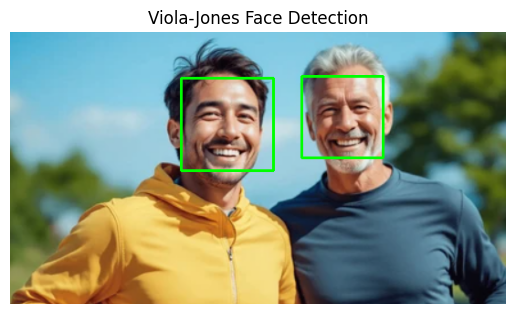

Number of faces detected: 2


In [3]:
# Install
!pip install opencv-python matplotlib -q

# Imports
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# -----------------------------
# Upload and Read Image
# -----------------------------
def load_image():
    uploaded_file = files.upload()
    file_name = list(uploaded_file.keys())[0]
    img = cv2.imread(str(file_name))
    return img

# -----------------------------
# Display Utility
# -----------------------------
def display(img, title, gray=False):
    plt.figure()
    if gray:
        plt.imshow(img, cmap='gray')
    else:
        plt.imshow(img)
    plt.title(title)
    plt.axis("off")
    plt.show()

# -----------------------------
# Convert to RGB
# -----------------------------
def to_rgb(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# -----------------------------
# Convert to Grayscale
# -----------------------------
def to_gray(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# -----------------------------
# Generate Haar-like Features
# -----------------------------
def haar_features(gray):
    gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=5)
    gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=5)
    return np.hypot(gx, gy)   # different from magnitude()

# -----------------------------
# Detect Faces (Viola-Jones)
# -----------------------------
def get_faces(gray):
    model = cv2.CascadeClassifier(
        cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
    )
    return model.detectMultiScale(gray, scaleFactor=1.3, minNeighbors=5)

# -----------------------------
# Draw Bounding Boxes
# -----------------------------
def mark_faces(rgb_img, faces):
    result = rgb_img.copy()
    for fx, fy, fw, fh in faces:
        cv2.rectangle(result, (fx, fy), (fx+fw, fy+fh), (0,255,0), 2)
    return result

# -----------------------------
# MAIN FLOW
# -----------------------------
image = load_image()
rgb = to_rgb(image)

# Original
display(rgb, "Original Image")

# Grayscale
gray = to_gray(image)
display(gray, "Grayscale Image", gray=True)

# Haar-like
haar_img = haar_features(gray)
display(haar_img, "Haar-like Feature Representation", gray=True)

# Face Detection
faces = get_faces(gray)

# Draw faces
final_img = mark_faces(rgb, faces)

# Final output
display(final_img, "Viola-Jones Face Detection")

# Count
print("Number of faces detected:", len(faces))